In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [24]:
df_exp1 = pd.read_csv('data/resultados_exp1.csv')
t_prom_exp1 = df_exp1['tiempo_total'].mean()

df_exp2 = pd.read_csv('data/resultados_rendimiento.csv')

df_prom = df_exp2.groupby('Streams').mean().reset_index()
df_prom['var'] = df_exp2.groupby('Streams')['Tiempo_ms'].var().reset_index()['Tiempo_ms']
df_prom['stddev'] = np.sqrt(df_prom['var'])
df_exp1.describe()

,tiempo_copia_H2D,tiempo_computo,tiempo_copia_D2H,tiempo_total
count,32.000000,32.000000,32.000000,32.000000
mean,1.591885,412.626094,1687.417188,2101.636250
std,0.332599,5.156218,199.495300,200.430715
min,1.276990,405.065000,1275.540000,1686.250000
25%,1.343173,408.370250,1555.542500,1965.470000
50%,1.450500,411.970500,1694.675000,2116.985000
75%,1.780067,416.965000,1797.425000,2213.797500
max,2.644640,427.947000,2195.080000,2608.330000


/tmp/ipykernel_31347/2862879284.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  t_prom_1s = float(stream1['Tiempo_ms'])


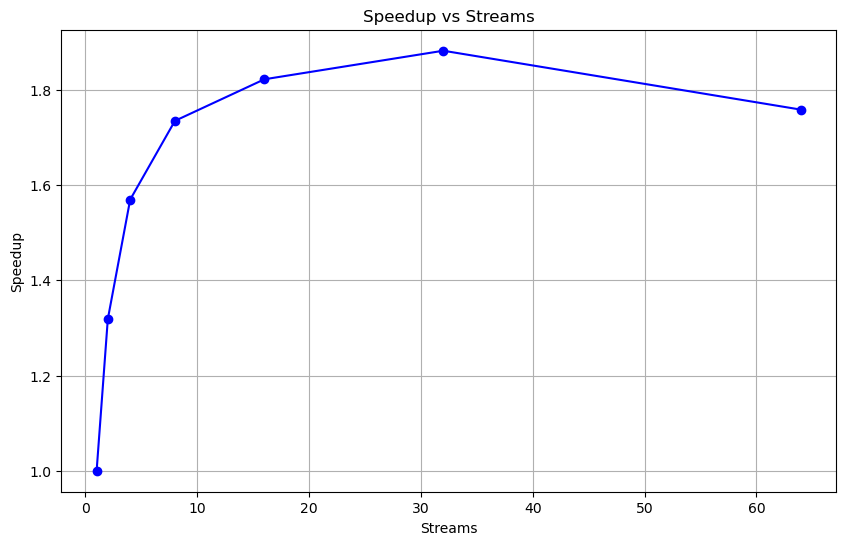

In [21]:
stream1 = df_prom[df_prom['Streams'] == 1]
t_prom_1s = float(stream1['Tiempo_ms'])

speedup = t_prom_1s /df_prom['Tiempo_ms'] 
eficiencia = speedup / df_prom["Streams"]

plt.figure(figsize=(10, 6))
plt.plot(df_prom['Streams'], speedup, marker='o', linestyle='-', color='b')
plt.title('Speedup vs Streams')
plt.xlabel('Streams')
plt.ylabel('Speedup')
# plt.xscale('log')
plt.grid()
plt.savefig('speedup_vs_streams.png')


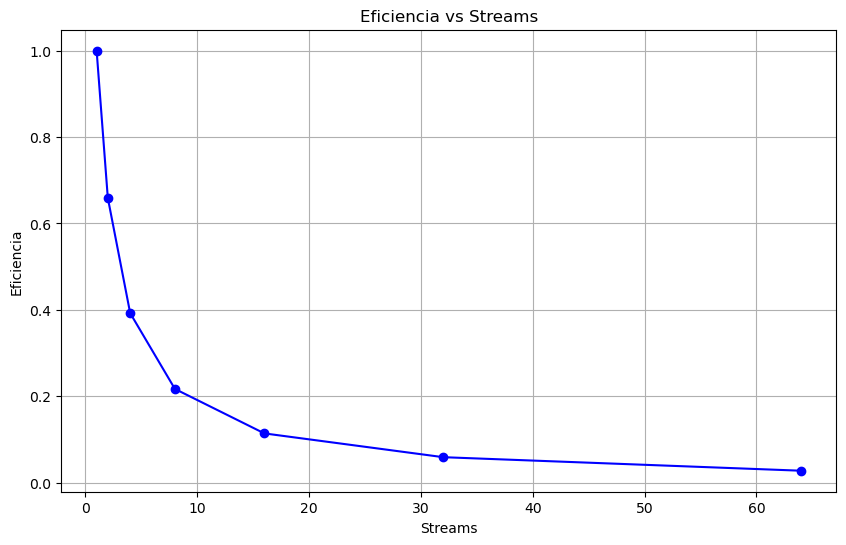

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(df_prom['Streams'], eficiencia, marker='o', linestyle='-', color='b')
plt.title('Eficiencia vs Streams')
plt.xlabel('Streams')
plt.ylabel('Eficiencia')
plt.grid()
plt.savefig('eficiencia_vs_streams.png')